# 평균 이동(Mean Shift)
* K-평균과 공통점 : 중심을 군집의 중심으로 지속적으로 움직이며 군집화 수행
* K-평균과 차이점
  * K-평균 : 중심에 소속된 데이터의 평균 거리 중심으로 이동
  * 평균 이동 : 중심을 데이터가 모여 있는 밀도 가장 높은 곳으로 이동시킴
* 데이터의 분포도를 이용해 군집 중심점을 찾음
  * 확률 밀도 함수(probability density function)을 이용
  * 가장 집중적으로 데이터가 모여 있음 -> 확률 밀도 함수 피크임 -> 군짐 중심점으로 선정
  * 확률 밀도 함수 찾기 위해 KDE(Kernel Density Estimation) 이용
* 주변 데이터와의 거리값을 KDE 함수값으로 입력 -> 반환값을 현재 위치에서 업데이트하면서 이동 -> 특정 데이터를 반경 내에 데이터 분포 확률 밀도가 가장 높으로 곳으로 이동시키게 됨 -> 전체 데이터 대해 반복 적용 -> 데이터의 군집 중심점을 찾아냄
* 자세한 과정
  * 개별 데이터의 특정 반경 내에, 주변 데이터를 포함한 데이터 분포도를, KDE기반의 평균 이동 알고리즘으로 계산
  * -> KDE로 계산된 데이터 분포도가 높은 방향으로 데이터 이동
  * -> 모든 데이터를 위 두 단계를 수행하며 데이터를 이동. 개별 데이터들이 군집 중심점으로 모임
  * -> 지정된 반복 횟수만큼 전체 데이터에 대해 KDE 기반으로 데이터를 이동시키며 군집화 수행
  * -> 개별 데이터들이 모인 중심점을 군집 중심점으로 설정


# KDE
* 커널 함수를 통해 어떤 변수의 확률 밀도 함수를 추정하는 방법 중 하나
* 관측된 데이터 각각에 커널 함수를 적용한 값을 모두 더함 -> 데이터 건수로 나눔 --> 확률 밀도 함수를 추정할 수 있음
* 확률 밀도 함수
  * 확률 변수의 분포를 나타내는 함수
  * 정규분포 함수, 감마 분포, t-분포 등이 있음
  * 확률 밀도 함수를 알면, 특정 변수가 어떤 값을 갖게 될지 대한 확률을 앎 -> 변수 특성(ex. 평균, 분산), 확률 분포 등 변수의 많은 요소 알 수 있음
* 개별 관측 데이터에 커널 함수 적용 -> 이 적용값 모두 더함 -> 개별 관측 데이터의 건수로 나눔 --> 확률 밀도 함수 추정됨
* 커널함수로 가우시안 분포 함수가 사용됨. 아래 그림의 위쪽은 개별 관측 데이터에 가우시안 커널 함수를 적용한 것, 아래쪽은 적용값을 모두 더한 KDE 결과
  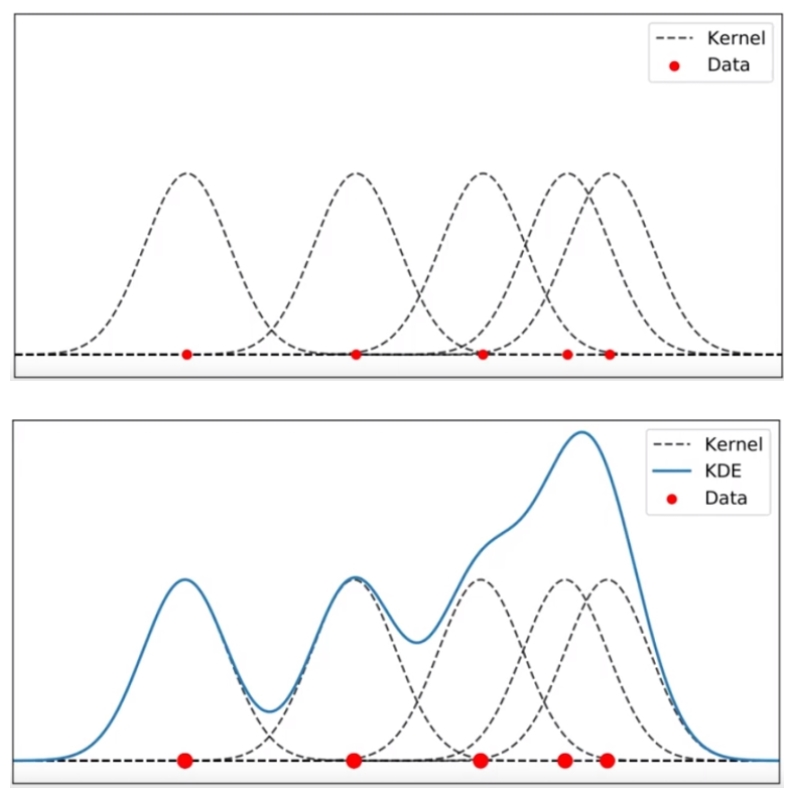
* 커널함수식(K=커널함수, x=확률변숫값, xi=관측값, h=대역폭(bandwidth)
  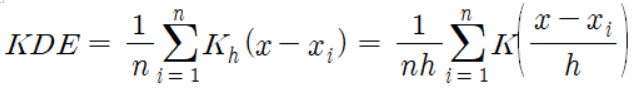
* 대역폭 h : KDE 형태를 부드럽거나 뾰족한 평태로 평활화(smooting)하는 데 사용. 확률 밀도 추정 성능 크게 좌우
  * 작은 h 값 : 좁고 뾰족한 KDE -> 변동성이 큰 방식으로 확률 밀도 함수 추정 -> overfitting 위험, 적은 수의 군집 중심점 가짐
  * 큰 h 값 : 과도하게 평활화된 KDE -> 지나치게 단순화된 방식으로 확률밀도 함수 추정 -> 과소적합(under-fitting) 위험, 많은 수의 군집 중심점 가짐
  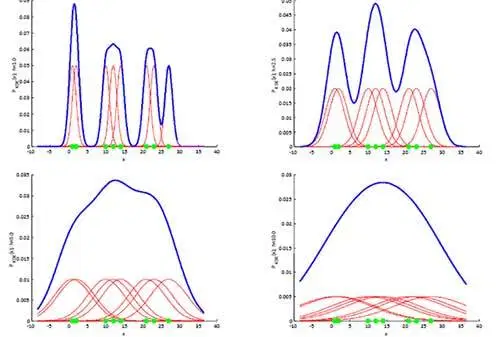
* 군집의 개수를 지정하지 않음 -> KDE 커널 함수의 대역폭 크기에 따라서만 군집화 수행

# 사이킷런 MeanShift 클래스
* 평균 이동 군집화를 위한 클래스
* 중요한 초기 파라미터는 대역혹인 bandwidth
* 최적의 대역폭 계산 위해 estimate_bandwidth() 함수 제공

In [2]:
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.cluster import MeanShift

x, y = make_blobs(n_samples=200, n_features=2, centers=3, cluster_std=0.7, random_state=0)
meanshift = MeanShift(bandwidth=0.8)
cluster_labels = meanshift.fit_predict(x)
print('cluster lables 유형 : ', np.unique(cluster_labels))

cluster lables 유형 :  [0 1 2 3 4 5]


In [4]:
# 위 결과, 군집이 6개로 분류되어 지나치게 세분화됨. 대역폭 높여보기
meanshift = MeanShift(bandwidth=1.0)
cluster_labels = meanshift.fit_predict(x)
print('cluster lables 유형 : ', np.unique(cluster_labels))

cluster lables 유형 :  [0 1 2]


In [5]:
# 최적의 대역폭 찾아보기
from sklearn.cluster import estimate_bandwidth

bandwidth = estimate_bandwidth(x)
print('bandwidth값 : ', round(bandwidth, 3))

bandwidth값 :  1.816


In [7]:
import pandas as pd

clusterDF = pd.DataFrame(data=x, columns=['ftr1', 'ftr2'])
clusterDF['target'] = y

best_bandwidth = estimate_bandwidth(x)
meanshift = MeanShift(bandwidth=best_bandwidth)
cluster_labels = meanshift.fit_predict(x)
print('cluster lables 유형 : ', np.unique(cluster_labels))

cluster lables 유형 :  [0 1 2]


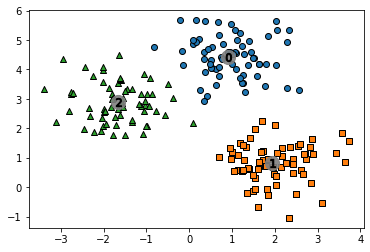

In [9]:
# 위 3개의 군집을 시각화

import matplotlib.pyplot as plt
%matplotlib inline

clusterDF['mean_shift_label'] = cluster_labels
centers = meanshift.cluster_centers_
unique_labels = np.unique(cluster_labels)
markers=['o', 's', '^', 'x', '*']

for label in unique_labels:
    label_cluster = clusterDF[clusterDF['mean_shift_label']==label]
    center_x_y = centers[label]
    plt.scatter(x=label_cluster['ftr1'], y=label_cluster['ftr2'], edgecolor='k', marker=markers[label])
    plt.scatter(x=center_x_y[0], y=center_x_y[1], s=200, color='gray', alpha=0.9) #군집별 중심
    plt.scatter(x=center_x_y[0], y=center_x_y[1], s=70, color='k', edgecolor='k', marker='$%d$' % label)
plt.show()

In [10]:
# target과 군집 label 비교

print(clusterDF.groupby('target')['mean_shift_label'].value_counts()) #1대 1로 잘 매칭됨

target  mean_shift_label
0       0                   67
1       1                   67
2       2                   66
Name: mean_shift_label, dtype: int64


# 평균 이동의 장단점
* 장점
  * 유연한 군집화가 가능 : 데이터셋의 형태를 특정 형태로 가정/특정 분포도 기반 모델로 가정 안함
  * 이상치의 영향력 크지 않음
  * 군집 개수 미리 정하지 않아도 됨
* 단점
  * 수행시간 긺
  * 대역폭 크기에 따른 군집화 영향도가 매우 큼
* 분석 업무 기반의 데이터셋보다는 컴퓨터 비전 영역에서 더 많이 사용됨 -> 특정 개체물 구분/ 움직임 추적 시 뛰어난 역할 수행하는 알고리즘임